# Oil Slick Detection — Baseline CNN Pipeline
**Seminar: Deep Learning for Maritime Vision Applications**

This notebook:
1. Downloads the WaterBench OilSlick S1 dataset
2. Explores the data (visualisations, class balance, metadata)
3. Trains a ResNet-18 baseline (2-channel VV/VH input)
4. Evaluates on random & geographic (Mediterranean OOD) splits
5. Shows confusion matrices and sample predictions

## 0 — Install Dependencies

In [ ]:
# !pip install -q huggingface_hub rasterio tifffile scikit-learn matplotlib seaborn

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
# Cell 2 — Point to existing data on Drive
import os

DATA_ROOT = "/content/drive/MyDrive/waterbench_2"
OILSLICK  = os.path.join(DATA_ROOT, "data", "OilSlick")   # metadata + splits live here
img_dir   = "/content/drive/MyDrive/waterbench_2/data/OilSlick/images_s1"

# Sanity check
tif_count = len([f for f in os.listdir(img_dir) if f.endswith(".tif")])
print(f"img_dir  : {img_dir}")
print(f"TIF files: {tif_count}  (expected 1363)")
print(f"metadata : {os.path.exists(os.path.join(OILSLICK, 'metadata.csv'))}")
print(f"splits   : {os.path.exists(os.path.join(OILSLICK, 'splits'))}")

img_dir  : /content/drive/MyDrive/waterbench_2/data/OilSlick/images_s1
TIF files: 981  (expected 1363)
metadata : True
splits   : True


## 2 — Data Exploration

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import rasterio

sns.set_style("whitegrid")

# ── 2.1  Load metadata ──────────────────────────────────────────────────────
meta = pd.read_csv(os.path.join(OILSLICK, "metadata.csv"))
print(f"Metadata shape: {meta.shape}")
print(f"\nColumns:\n{list(meta.columns)}")
meta.head()

Metadata shape: (1363, 24)

Columns:
['sample_id', 'label', 'subcategory', 'source_date', 'center_lon', 'center_lat', 'date_diff_days', 'nodata_fraction', 'is_valid', 'image_path', 'rgb_path', 'swir_path', 'n_bands', 'band_order', 'scene_id', 'scene_datetime', 'platform', 'cloud_cover', 'sun_azimuth', 'sun_elevation', 'proj_epsg', 'reflectance_min', 'reflectance_max', 'reflectance_mean']


,sample_id,label,subcategory,source_date,center_lon,center_lat,date_diff_days,nodata_fraction,is_valid,image_path,...,scene_id,scene_datetime,platform,cloud_cover,sun_azimuth,sun_elevation,proj_epsg,reflectance_min,reflectance_max,reflectance_mean
0,pos_00001,1,Ships,20170626,34.8720,25.6463,1,0.0,True,images/positive/pos_00001.tif,...,S2A_MSIL2A_20170627T081001_R078_T36RXP_2021021...,2017-06-27T08:10:01.026000+00:00,Sentinel-2A,0.078479,-1,-1,NaN,0.0288,0.1538,0.049075
1,pos_00007,1,Ships,20170501,14.8150,35.8750,-1,0.0,True,images/positive/pos_00007.tif,...,S2B_MSIL2A_20170430T094029_R036_T33SVV_2021020...,2017-04-30T09:40:29.027000+00:00,Sentinel-2B,21.981618,-1,-1,NaN,0.0001,0.3322,0.022737
2,pos_00013,1,Platforms,20160526,0.9269,57.7068,1,0.0,True,images/positive/pos_00013.tif,...,S2A_MSIL2A_20160527T110702_R137_T31VCE_2021021...,2016-05-27T11:07:02.027000+00:00,Sentinel-2A,0.857883,-1,-1,NaN,0.0001,1.0000,0.010534
3,pos_00017,1,Ships,20190726,128.3855,-14.3665,1,0.0,True,images/positive/pos_00017.tif,...,S2A_MSIL2A_20190727T014701_R074_T52LDK_2020110...,2019-07-27T01:47:01.024000+00:00,Sentinel-2A,18.741675,-1,-1,NaN,0.0001,0.1638,0.015806
4,pos_00022,1,Ships,20180319,104.8076,1.5932,0,0.0,True,images/positive/pos_00022.tif,...,S2B_MSIL2A_20180319T030539_R075_T48NVG_2020101...,2018-03-19T03:05:39.027000+00:00,Sentinel-2B,25.441538,-1,-1,NaN,0.0051,1.0000,0.045527


In [ ]:
# Load full metadata for label lookup (before any filtering)
meta_full = pd.read_csv(os.path.join(OILSLICK, "metadata.csv"))
full_label_map = dict(zip(meta_full["sample_id"], meta_full["label"]))
print(f"Full label map: {len(full_label_map)} entries")

Full label map: 1363 entries


In [ ]:
# Keep only pos and neg, exclude ext_pos and ext_neg
meta = meta[~meta["sample_id"].str.startswith("ext")].reset_index(drop=True)

print(f"Filtered metadata: {len(meta)} rows")
print(meta["label"].value_counts())

Filtered metadata: 1000 rows
label
1    500
0    500
Name: count, dtype: int64


In [ ]:
import os

img_dir = "/content/drive/MyDrive/waterbench_2/data/OilSlick/images_s1"

# Build set of sample IDs that actually exist on disk
available_ids = set(
    f.replace("_s1.tif", "") for f in os.listdir(img_dir) if f.endswith(".tif")
)

# Filter meta to only those IDs
meta = meta[meta["sample_id"].isin(available_ids)].reset_index(drop=True)

print(f"Available on disk : {len(available_ids)}")
print(f"Metadata rows kept: {len(meta)}")
print(meta["label"].value_counts())

Available on disk : 981
Metadata rows kept: 970
label
1    486
0    484
Name: count, dtype: int64


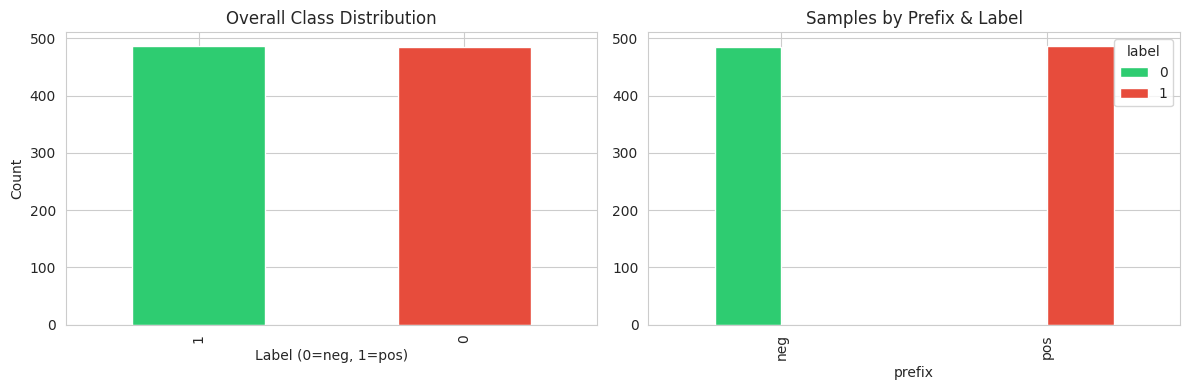

In [ ]:
# ── 2.2  Class distribution ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Overall
meta["label"].value_counts().plot.bar(ax=axes[0], color=["#2ecc71", "#e74c3c"])
axes[0].set_title("Overall Class Distribution")
axes[0].set_xlabel("Label (0=neg, 1=pos)")
axes[0].set_ylabel("Count")

# By prefix
meta["prefix"] = meta["sample_id"].str.extract(r"^(pos|neg|ext_pos|ext_neg)")
meta.groupby(["prefix", "label"]).size().unstack(fill_value=0).plot.bar(
    ax=axes[1], color=["#2ecc71", "#e74c3c"]
)
axes[1].set_title("Samples by Prefix & Label")
plt.tight_layout()
plt.show()

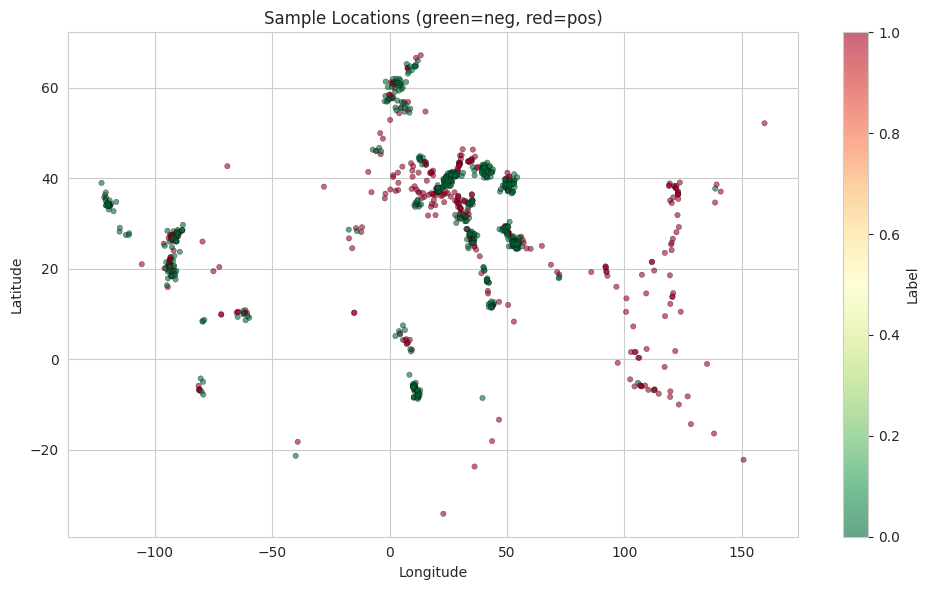

In [ ]:
# ── 2.3  Geographic distribution ────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))
scatter = ax.scatter(
    meta["center_lon"], meta["center_lat"],
    c=meta["label"], cmap="RdYlGn_r", alpha=0.6, s=15,
    edgecolors="k", linewidths=0.3,
)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Sample Locations (green=neg, red=pos)")
plt.colorbar(scatter, ax=ax, label="Label")
plt.tight_layout()
plt.show()

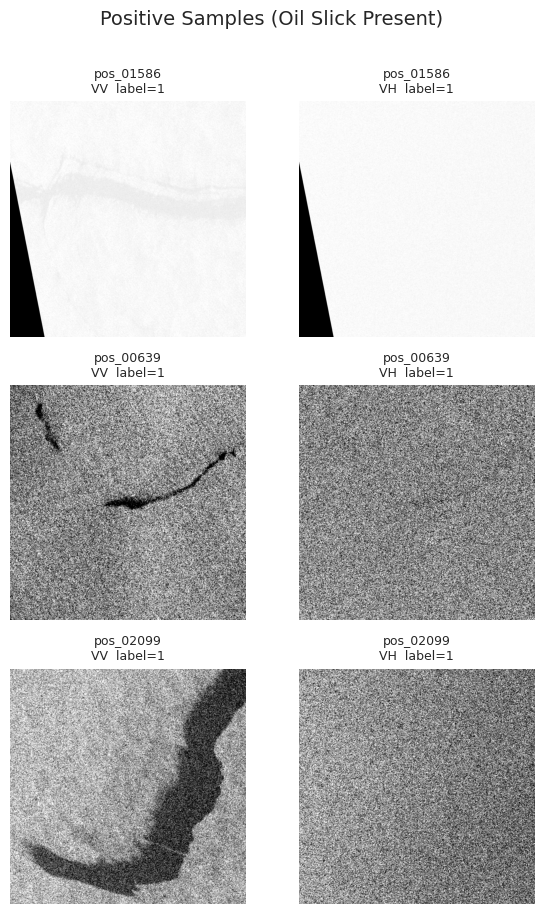

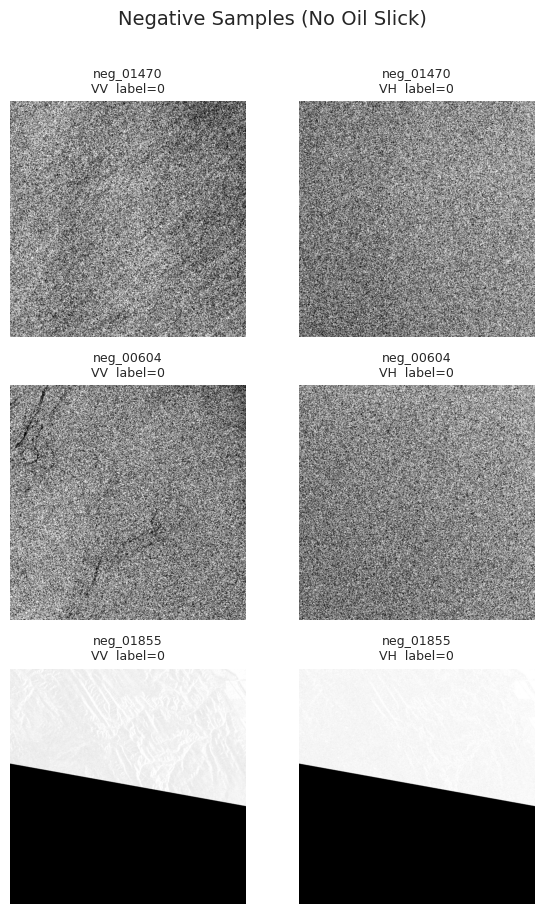

In [ ]:
# ── 2.4  Visualise sample chips ─────────────────────────────────────────────

def load_chip(sample_id):
    """Load a 2-band S1 chip as numpy array (2, 224, 224)."""
    path = os.path.join(img_dir, f"{sample_id}_s1.tif")
    with rasterio.open(path) as src:
        data = src.read()  # shape: (2, H, W)
    return data


def show_chips(sample_ids, labels, title=""):
    """Show VV and VH bands side by side for a list of samples."""
    n = len(sample_ids)
    fig, axes = plt.subplots(n, 2, figsize=(6, 3 * n))
    if n == 1:
        axes = axes[np.newaxis, :]
    fig.suptitle(title, fontsize=14, y=1.01)
    for i, (sid, lab) in enumerate(zip(sample_ids, labels)):
        chip = load_chip(sid)
        for j, band_name in enumerate(["VV", "VH"]):
            ax = axes[i, j]
            band = chip[j]
            vmin, vmax = np.percentile(band[band != 0], [2, 98])
            ax.imshow(band, cmap="gray", vmin=vmin, vmax=vmax)
            ax.set_title(f"{sid}\n{band_name}  label={lab}", fontsize=9)
            ax.axis("off")
    plt.tight_layout()
    plt.show()


# Show 3 positive + 3 negative examples
pos_ids = meta[meta["label"] == 1]["sample_id"].sample(3, random_state=41).tolist()
neg_ids = meta[meta["label"] == 0]["sample_id"].sample(3, random_state=41).tolist()

show_chips(pos_ids, [1] * 3, title="Positive Samples (Oil Slick Present)")
show_chips(neg_ids, [0] * 3, title="Negative Samples (No Oil Slick)")

In [ ]:
import os

files = os.listdir(img_dir)
tif_files = [f for f in files if f.endswith(".tif")]

# Count by prefix
from collections import Counter
prefixes = Counter(f.split("_")[0] + "_" + f.split("_")[1]
                   if f.startswith("ext") else f.split("_")[0]
                   for f in tif_files)
print("Files on Drive by prefix:")
for prefix, count in sorted(prefixes.items()):
    print(f"  {prefix}: {count}")
print(f"  TOTAL: {len(tif_files)}")

Files on Drive by prefix:
  ext_pos: 11
  neg: 484
  pos: 486
  TOTAL: 981


## Per-Channel Statistics

The raw pixel values from the SAR GeoTIFF are in **decibel (dB) scale**,
typically ranging from -30 to 0 dB for open ocean scenes.

Key observations from our data:
- **Mean VV: -28.8, Mean VH: -36.8** — typical open ocean backscatter
- **Std VV: 42.6, Std VH: 39.1** — unusually high, driven by outliers
- **Min: -163** — nodata sentinel value, must be masked
- **Max: ~1997** — extreme outliers from ships or coastlines

Since these outliers would dominate z-score normalisation and squash the
meaningful ocean signal, we clip values to the range [-50, 10] dB before
normalising.

In [ ]:
# ── 2.5  Per-channel statistics ──────────────────────────────────────────────
print("Computing per-channel statistics on a sample of chips...")
rng = np.random.RandomState(0)
sample_ids_all = meta["sample_id"].values
subset = rng.choice(sample_ids_all, size=min(200, len(sample_ids_all)), replace=False)

all_vv, all_vh = [], []
for sid in subset:
    chip = load_chip(sid)
    valid = chip != 0  # mask nodata
    all_vv.append(chip[0][valid[0]])
    all_vh.append(chip[1][valid[1]])

all_vv = np.concatenate(all_vv)
all_vh = np.concatenate(all_vh)

print(f"VV — mean: {all_vv.mean():.4f}, std: {all_vv.std():.4f}, "
      f"min: {all_vv.min():.4f}, max: {all_vv.max():.4f}")
print(f"VH — mean: {all_vh.mean():.4f}, std: {all_vh.std():.4f}, "
      f"min: {all_vh.min():.4f}, max: {all_vh.max():.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(all_vv, bins=100, color="steelblue", alpha=0.7)
axes[0].set_title("VV Backscatter Distribution")
axes[1].hist(all_vh, bins=100, color="darkorange", alpha=0.7)
axes[1].set_title("VH Backscatter Distribution")
plt.tight_layout()
plt.show()

Computing per-channel statistics on a sample of chips...


## 3 — Dataset & DataLoader

In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader


class OilSlickDataset(Dataset):
    def __init__(self, split_file, img_dir, label_map,
                 vv_mean, vv_std, vh_mean, vh_std, augment=False):

        available = set(
            f.replace("_s1.tif", "") for f in os.listdir(img_dir) if f.endswith(".tif")
        )

        with open(split_file) as f:
            all_ids = [line.strip() for line in f if line.strip()]

        # Only keep IDs that exist on disk AND have a label
        self.sample_ids = [sid for sid in all_ids
                           if sid in available and sid in label_map]

        skipped = len(all_ids) - len(self.sample_ids)
        if skipped > 0:
            print(f"  [{split_file.split('/')[-1]}] Skipped {skipped}, "
                  f"using {len(self.sample_ids)}")

        self.img_dir = img_dir
        self.label_map = label_map
        self.vv_mean, self.vv_std = vv_mean, vv_std
        self.vh_mean, self.vh_std = vh_mean, vh_std
        self.augment = augment

    def __len__(self):
        return len(self.sample_ids)

    def __getitem__(self, idx):
      sid = self.sample_ids[idx]
      path = os.path.join(self.img_dir, f"{sid}_s1.tif")
      with rasterio.open(path) as src:
          chip = src.read().astype(np.float32)

      # Clean
      chip[chip == -163.0] = 0.0
      chip[0] = np.clip(chip[0], -50, 10)
      chip[1] = np.clip(chip[1], -50, 10)

      # Z-score normalise
      chip[0] = (chip[0] - self.vv_mean) / (self.vv_std + 1e-8)
      chip[1] = (chip[1] - self.vh_mean) / (self.vh_std + 1e-8)

      chip = torch.from_numpy(chip)

      if self.augment:
          # Flips
          if torch.rand(1).item() > 0.5:
              chip = torch.flip(chip, dims=[2])
          if torch.rand(1).item() > 0.5:
              chip = torch.flip(chip, dims=[1])
          # 90° rotations
          k = torch.randint(0, 4, (1,)).item()
          chip = torch.rot90(chip, k, dims=[1, 2])
          # Small Gaussian noise
          chip = chip + 0.05 * torch.randn_like(chip)

      label = torch.tensor(self.label_map[sid], dtype=torch.float32)
      return chip, label

In [ ]:
# ── 3.1  Compute normalisation stats on RANDOM training split ───────────────

def compute_channel_stats(split_file, img_dir):
    """Compute per-channel mean and std from training samples."""
    with open(split_file) as f:
        train_ids = [line.strip() for line in f if line.strip()]
    # train_ids = [sid for sid in train_ids if sid in available]

    vv_vals, vh_vals = [], []
    for sid in train_ids:
        path = os.path.join(img_dir, f"{sid}_s1.tif")
        with rasterio.open(path) as src:
            chip = src.read().astype(np.float32)
        mask = chip != 0
        vv_vals.append(chip[0][mask[0]])
        vh_vals.append(chip[1][mask[1]])

    vv_all = np.concatenate(vv_vals)
    vh_all = np.concatenate(vh_vals)
    return vv_all.mean(), vv_all.std(), vh_all.mean(), vh_all.std()


random_train_file = os.path.join(OILSLICK, "splits", "random", "train.txt")
vv_mean, vv_std, vh_mean, vh_std = compute_channel_stats(random_train_file, img_dir)
print(f"Training stats — VV: μ={vv_mean:.4f} σ={vv_std:.4f}  |  "
      f"VH: μ={vh_mean:.4f} σ={vh_std:.4f}")

In [ ]:
# Check what IDs are in the train split vs what's on disk
with open(random_train_file) as f:
    train_ids = [line.strip() for line in f if line.strip()]

available = set(f.replace("_s1.tif", "") for f in os.listdir(img_dir) if f.endswith(".tif"))

missing  = [sid for sid in train_ids if sid not in available]
present  = [sid for sid in train_ids if sid in available]

print(f"Total in train.txt : {len(train_ids)}")
print(f"Available on disk  : {len(present)}")
print(f"Missing            : {len(missing)}")
print(f"Sample missing IDs : {missing[:5]}")

In [ ]:
def compute_channel_stats(split_file, img_dir):
    """Memory-efficient per-channel mean and std using vectorised Welford's algorithm."""
    available = set(
        f.replace("_s1.tif", "") for f in os.listdir(img_dir) if f.endswith(".tif")
    )

    with open(split_file) as f:
        train_ids = [line.strip() for line in f if line.strip()]
    train_ids = [sid for sid in train_ids if sid in available]
    print(f"Computing stats over {len(train_ids)} training chips...")

    vv_count = vv_mean = vv_M2 = 0.0
    vh_count = vh_mean = vh_M2 = 0.0

    for i, sid in enumerate(train_ids):
        path = os.path.join(img_dir, f"{sid}_s1.tif")
        with rasterio.open(path) as src:
            chip = src.read().astype(np.float32)

        # Clean
        chip[chip == -163.0] = np.nan
        chip[0] = np.clip(chip[0], -50, 10)
        chip[1] = np.clip(chip[1], -50, 10)

        # VV — vectorised Welford merge
        vv_pixels = chip[0][~np.isnan(chip[0])].ravel()
        n = len(vv_pixels)
        if n > 0:
            batch_mean = vv_pixels.mean()
            batch_var  = vv_pixels.var()
            delta      = batch_mean - vv_mean
            vv_mean    = (vv_mean * vv_count + batch_mean * n) / (vv_count + n)
            vv_M2     += batch_var * n + delta**2 * vv_count * n / (vv_count + n)
            vv_count  += n

        # VH — vectorised Welford merge
        vh_pixels = chip[1][~np.isnan(chip[1])].ravel()
        n = len(vh_pixels)
        if n > 0:
            batch_mean = vh_pixels.mean()
            batch_var  = vh_pixels.var()
            delta      = batch_mean - vh_mean
            vh_mean    = (vh_mean * vh_count + batch_mean * n) / (vh_count + n)
            vh_M2     += batch_var * n + delta**2 * vh_count * n / (vh_count + n)
            vh_count  += n

        if (i + 1) % 100 == 0:
            print(f"  Processed {i+1}/{len(train_ids)} chips...")

    vv_std = np.sqrt(vv_M2 / vv_count)
    vh_std = np.sqrt(vh_M2 / vh_count)

    print(f"Done ✓")
    return float(vv_mean), float(vv_std), float(vh_mean), float(vh_std)


random_train_file = os.path.join(OILSLICK, "splits", "random", "train.txt")
vv_mean, vv_std, vh_mean, vh_std = compute_channel_stats(random_train_file, img_dir)
print(f"\nTraining stats — VV: μ={vv_mean:.4f} σ={vv_std:.4f}  |  "
      f"VH: μ={vh_mean:.4f} σ={vh_std:.4f}")

In [ ]:
# ── 3.2  Build loaders for a given split ────────────────────────────────────
BATCH_SIZE = 32


def make_loaders(split_name, vv_mean, vv_std, vh_mean, vh_std):
    split_dir = os.path.join(OILSLICK, "splits", split_name)
    ds_train = OilSlickDataset(
        os.path.join(split_dir, "train.txt"), img_dir, full_label_map,
        vv_mean, vv_std, vh_mean, vh_std, augment=True,
    )
    ds_val = OilSlickDataset(
        os.path.join(split_dir, "val.txt"), img_dir, full_label_map,
        vv_mean, vv_std, vh_mean, vh_std, augment=False,
    )
    ds_test = OilSlickDataset(
        os.path.join(split_dir, "test.txt"), img_dir, full_label_map,
        vv_mean, vv_std, vh_mean, vh_std, augment=False,
    )
    loader_train = DataLoader(ds_train, batch_size=BATCH_SIZE, shuffle=True,
                              num_workers=2, pin_memory=True)
    loader_val   = DataLoader(ds_val,   batch_size=BATCH_SIZE, shuffle=False,
                              num_workers=2, pin_memory=True)
    loader_test  = DataLoader(ds_test,  batch_size=BATCH_SIZE, shuffle=False,
                              num_workers=2, pin_memory=True)
    print(f"[{split_name}] train={len(ds_train)}, val={len(ds_val)}, test={len(ds_test)}")
    return loader_train, loader_val, loader_test


rand_train, rand_val, rand_test = make_loaders(
    "random", vv_mean, vv_std, vh_mean, vh_std
)

In [ ]:
import tensorflow as tf
class F1EarlyStopping(tf.keras.callbacks.Callback):
    def __init__(self, validation_data, patience=10):
        super().__init__()
        self.val_data = validation_data
        self.patience = patience
        self.best_f1 = 0
        self.wait = 0
        self.best_weights = None
        self.best_epoch = 0

    def on_epoch_end(self, epoch, logs=None):
        x_val, y_val = self.val_data
        y_pred = (self.model.predict(x_val, verbose=0) > 0.5).astype(int)
        f1 = f1_score(y_val, y_pred, average='macro')
        logs['val_f1'] = f1
        print(f" — val_f1: {f1:.4f}")

        if f1 > self.best_f1:
            self.best_f1 = f1
            self.wait = 0
            self.best_weights = self.model.get_weights()
            self.best_epoch = epoch
        else:
            self.wait += 1
            if self.wait >= self.patience:
                print(f"\nEarly stopping. Best F1: {self.best_f1:.4f} at epoch {self.best_epoch}")
                self.model.set_weights(self.best_weights)
                self.model.stop_training = True

In [ ]:
from sklearn.metrics import f1_score, precision_recall_curve
import numpy as np

def find_optimal_threshold(model, x_val, y_val):
    y_probs = model.predict(x_val, verbose=0).ravel()

    thresholds = np.arange(0.1, 0.9, 0.01)
    best_f1 = 0
    best_threshold = 0.5

    for threshold in thresholds:
        y_pred = (y_probs > threshold).astype(int)
        f1 = f1_score(y_val, y_pred, average='macro')
        if f1 > best_f1:
            best_f1 = f1
            best_threshold = threshold

    print(f"Optimal threshold: {best_threshold:.2f}")
    print(f"F1 at optimal threshold: {best_f1:.4f}")
    print(f"F1 at default 0.5: {f1_score(y_val, (y_probs > 0.5).astype(int), average='macro'):.4f}")

    return best_threshold

## 4 — ResNet-18 Baseline (2-channel Input)

In [ ]:
import torch.nn as nn
import torchvision.models as models


def build_resnet18_2ch(pretrained_init=True):
    """
    ResNet-18 adapted for 2-channel (VV, VH) input.
    - Replaces conv1: 3 → 2 input channels
    - Replaces fc: 512 → 1 output (binary classification)
    If pretrained_init=True, loads ImageNet weights and blends
    the 3-channel conv1 weights into 2 channels.
    """
    weights = models.ResNet18_Weights.DEFAULT if pretrained_init else None
    net = models.resnet18(weights=weights)

    # Adapt first conv layer: 3 → 2 channels
    old_conv = net.conv1
    new_conv = nn.Conv2d(
        2, old_conv.out_channels,
        kernel_size=old_conv.kernel_size,
        stride=old_conv.stride,
        padding=old_conv.padding,
        bias=False,
    )
    if pretrained_init:
        with torch.no_grad():
            w = old_conv.weight.data  # (64, 3, 7, 7)
            # Blend: channel 0 gets R + half of B, channel 1 gets G + half of B
            new_conv.weight[:, 0] = w[:, 0] + w[:, 2] * 0.5
            new_conv.weight[:, 1] = w[:, 1] + w[:, 2] * 0.5
    net.conv1 = new_conv

    # Replace classifier head for binary output
    net.fc = nn.Linear(net.fc.in_features, 1)
    return net

def build_resnet18_v2(pretrained_init=True, dropout=0.4):
    """ResNet-18 with dropout before the classifier to reduce overfitting."""
    weights = models.ResNet18_Weights.DEFAULT if pretrained_init else None
    net = models.resnet18(weights=weights)

    # 2-channel input
    old_conv = net.conv1
    new_conv = nn.Conv2d(
        2, old_conv.out_channels,
        kernel_size=old_conv.kernel_size,
        stride=old_conv.stride,
        padding=old_conv.padding,
        bias=False,
    )
    if pretrained_init:
        with torch.no_grad():
            w = old_conv.weight.data
            new_conv.weight[:, 0] = w[:, 0] + w[:, 2] * 0.5
            new_conv.weight[:, 1] = w[:, 1] + w[:, 2] * 0.5
    net.conv1 = new_conv

    # Dropout + classifier
    net.fc = nn.Sequential(
        nn.Dropout(dropout),
        nn.Linear(512, 1),
    )
    return net


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

model = build_resnet18_v2(pretrained_init=True).to(device)
print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")

## 5 — Training Loop

In [ ]:
from sklearn.metrics import f1_score, roc_auc_score, accuracy_score


def evaluate(model, loader, device):
    """Evaluate model and return loss + metrics."""
    model.eval()
    criterion = nn.BCEWithLogitsLoss()
    all_logits, all_labels, total_loss = [], [], 0.0

    with torch.no_grad():
        for chips, labels in loader:
            chips, labels = chips.to(device), labels.to(device)
            logits = model(chips).squeeze(-1)
            total_loss += criterion(logits, labels).item() * len(labels)
            all_logits.append(logits.cpu())
            all_labels.append(labels.cpu())

    all_logits = torch.cat(all_logits)
    all_labels = torch.cat(all_labels)
    probs = torch.sigmoid(all_logits).numpy()
    labels_np = all_labels.numpy().astype(int)
    preds = (probs >= 0.5).astype(int)

    return {
        "loss": total_loss / len(all_labels),
        "accuracy": accuracy_score(labels_np, preds),
        "f1": f1_score(labels_np, preds, zero_division=0),
        "auroc": roc_auc_score(labels_np, probs)
                 if len(np.unique(labels_np)) > 1 else 0.0,
        "probs": probs,
        "labels": labels_np,
        "preds": preds,
    }

In [ ]:
from sklearn.metrics import f1_score

# Training with F1 early stopping
f1_callback = F1EarlyStopping(
    validation_data=(x_val, y_val),
    patience=10
)

history = model.fit(
    x_train, y_train,
    epochs=100,
    batch_size=32,
    validation_data=(x_val, y_val),
    callbacks=[f1_callback]
)

# After training, find optimal threshold on validation set
best_threshold = find_optimal_threshold(model, x_val, y_val)

# Evaluate on test set with optimal threshold
y_probs_test = model.predict(x_test, verbose=0).ravel()
y_pred_default = (y_probs_test > 0.5).astype(int)
y_pred_tuned = (y_probs_test > best_threshold).astype(int)

print(f"\nTest F1 (threshold=0.5): {f1_score(y_test, y_pred_default, average='macro'):.4f}")
print(f"Test F1 (threshold={best_threshold:.2f}): {f1_score(y_test, y_pred_tuned, average='macro'):.4f}")

In [ ]:
def train_model_v2(model, train_loader, val_loader, device,
                   epochs=60, lr=1e-4, patience=15,
                   label_smoothing=0.05, monitor="f1"):  # ← added monitor param

    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-3)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    criterion = nn.BCEWithLogitsLoss()

    history = {"train_loss": [], "val_loss": [], "val_f1": [], "val_auroc": []}
    best_score = 0.0
    best_state = None
    wait = 0

    for epoch in range(1, epochs + 1):
        model.train()
        running_loss = 0.0
        for chips, labels in train_loader:
            chips, labels = chips.to(device), labels.to(device)
            labels_smooth = labels * (1 - label_smoothing) + 0.5 * label_smoothing
            optimizer.zero_grad()
            logits = model(chips).squeeze(-1)
            loss = criterion(logits, labels_smooth)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * len(labels)

        train_loss = running_loss / len(train_loader.dataset)
        scheduler.step()

        val_metrics = evaluate(model, val_loader, device)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_metrics["loss"])
        history["val_f1"].append(val_metrics["f1"])
        history["val_auroc"].append(val_metrics["auroc"])

        # Pick which metric to monitor
        current_score = val_metrics["f1"] if monitor == "f1" else val_metrics["auroc"]

        lr_now = optimizer.param_groups[0]["lr"]
        print(
            f"Epoch {epoch:3d}/{epochs}  "
            f"train_loss={train_loss:.4f}  val_loss={val_metrics['loss']:.4f}  "
            f"val_F1={val_metrics['f1']:.4f}  val_AUROC={val_metrics['auroc']:.4f}  "
            f"lr={lr_now:.2e}"
            + (" ✓" if current_score > best_score else "")  # marks improvements
        )

        if current_score > best_score:
            best_score = current_score
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                print(f"Early stopping at epoch {epoch} "
                      f"(best val {monitor.upper()} = {best_score:.4f})")
                break

    if best_state is not None:
        model.load_state_dict(best_state)
        model.to(device)
    return model, history

In [ ]:
# # ═══════════════════════════════════════════════════════════════════════════
# # Train on the RANDOM split
# # ═══════════════════════════════════════════════════════════════════════════
# model_v2 = build_resnet18_v2(pretrained_init=True, dropout=0.4).to(device)
# model_v2, history_v2 = train_model_v2(
#     model_v2, rand_train, rand_val, device,
#     epochs=60, lr=3e-4, patience=15, label_smoothing=0.05
# )

In [ ]:
model_v3 = build_resnet18_v2(pretrained_init=True, dropout=0.4).to(device)

model_v3, history_v3 = train_model_v2(
    model_v3, rand_train, rand_val, device,
    epochs=80,
    lr=1e-4,        # back to stable LR — less spiking
    patience=20,    # more patience since F1 is noisy
    monitor="f1",   # ← monitor and restore on F1
)

In [ ]:
# ── 5.1  Plot training curves ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(history_v2["train_loss"], label="Train")
axes[0].plot(history_v2["val_loss"], label="Val")
axes[0].set_title("Loss")
axes[0].legend()

axes[1].plot(history_v2["val_f1"], color="green")
axes[1].set_title("Validation F1")

axes[2].plot(history_v2["val_auroc"], color="purple")
axes[2].set_title("Validation AUROC")

for ax in axes:
    ax.set_xlabel("Epoch")
plt.tight_layout()
plt.show()

## 6 — Evaluation

In [ ]:
from sklearn.metrics import (
    confusion_matrix, classification_report, ConfusionMatrixDisplay,
)


def full_eval(model, loader, device, split_name):
    """Evaluate and display confusion matrix + classification report."""
    results = evaluate(model_v2, loader, device)

    print(f"\n{'=' * 55}")
    print(f"  {split_name}")
    print(f"{'=' * 55}")
    print(f"  Accuracy : {results['accuracy']:.4f}")
    print(f"  F1 Score : {results['f1']:.4f}")
    print(f"  AUROC    : {results['auroc']:.4f}")
    print()
    print(classification_report(
        results["labels"], results["preds"],
        target_names=["No Slick", "Oil Slick"],
    ))

    cm = confusion_matrix(results["labels"], results["preds"])
    fig, ax = plt.subplots(figsize=(5, 4))
    ConfusionMatrixDisplay(
        cm, display_labels=["No Slick", "Oil Slick"]
    ).plot(ax=ax, cmap="Blues")
    ax.set_title(f"Confusion Matrix — {split_name}")
    plt.tight_layout()
    plt.show()
    return results


# ── 6.1  Random split — test set ────────────────────────────────────────────
rand_results = full_eval(model, rand_test, device, "Random Split (Test)")

In [ ]:
# ── 6.2  Geographic split — retrain & evaluate ──────────────────────────────

# Recompute normalisation stats for the geographic training set
geo_train_file = os.path.join(OILSLICK, "splits", "geographic", "train.txt")
geo_vv_m, geo_vv_s, geo_vh_m, geo_vh_s = compute_channel_stats(
    geo_train_file, img_dir
)

geo_train, geo_val, geo_test = make_loaders(
    "geographic", geo_vv_m, geo_vv_s, geo_vh_m, geo_vh_s
)

# Fresh model for geographic split
model_geo = build_resnet18_2ch(pretrained_init=True).to(device)
model_geo, history_geo = train_model(
    model_geo, geo_train, geo_val, device, epochs=40, lr=1e-4, patience=8
)

geo_results = full_eval(
    model_geo, geo_test, device, "Geographic Split (Mediterranean OOD Test)"
)

## 7 — Side-by-Side Summary

In [ ]:
summary = pd.DataFrame({
    "Metric": ["Accuracy", "F1 Score", "AUROC"],
    "Random Split": [
        f"{rand_results['accuracy']:.4f}",
        f"{rand_results['f1']:.4f}",
        f"{rand_results['auroc']:.4f}",
    ],
    "Geographic Split (OOD)": [
        f"{geo_results['accuracy']:.4f}",
        f"{geo_results['f1']:.4f}",
        f"{geo_results['auroc']:.4f}",
    ],
})

print("\n" + "=" * 55)
print("  ResNet-18 Baseline — Results Summary")
print("=" * 55)
print(summary.to_string(index=False))
print()

## 8 — Inspect Failure Cases

In [ ]:
def show_failures(results, split_name, loader, n=4):
    """Show the most confidently wrong predictions."""
    probs  = results["probs"]
    labels = results["labels"]
    preds  = results["preds"]

    wrong = np.where(preds != labels)[0]
    if len(wrong) == 0:
        print(f"No misclassifications on {split_name}!")
        return

    # Sort by confidence in the wrong direction
    confidence = np.abs(probs[wrong] - 0.5)
    top_wrong = wrong[np.argsort(-confidence)[:n]]

    dataset = loader.dataset
    fig, axes = plt.subplots(len(top_wrong), 2, figsize=(7, 3.5 * len(top_wrong)))
    if len(top_wrong) == 1:
        axes = axes[np.newaxis, :]
    fig.suptitle(f"Most Confident Errors — {split_name}", fontsize=13, y=1.01)

    for i, idx in enumerate(top_wrong):
        sid = dataset.sample_ids[idx]
        chip = load_chip(sid)
        true_label = labels[idx]
        pred_prob  = probs[idx]
        for j, band in enumerate(["VV", "VH"]):
            ax = axes[i, j]
            b = chip[j]
            vmin, vmax = np.percentile(b[b != 0], [2, 98])
            ax.imshow(b, cmap="gray", vmin=vmin, vmax=vmax)
            ax.set_title(
                f"{sid}\n{band} | true={true_label} pred={pred_prob:.2f}",
                fontsize=9,
            )
            ax.axis("off")
    plt.tight_layout()
    plt.show()


show_failures(rand_results, "Random Split", rand_test, n=4)
show_failures(geo_results, "Geographic Split (OOD)", geo_test, n=4)

## 9 — Save Model Checkpoints

In [ ]:
os.makedirs("/content/checkpoints", exist_ok=True)
torch.save(model.state_dict(), "/content/checkpoints/resnet18_random_split.pt")
torch.save(model_geo.state_dict(), "/content/checkpoints/resnet18_geographic_split.pt")
print("Checkpoints saved ✓")
# Download from Colab's file browser on the left panel.

## Next Steps

With this baseline in hand, the natural extensions are:

1. **GFM comparison** — Fine-tune TerraMind on the same splits and compare
2. **Grad-CAM** — `pip install pytorch-grad-cam` to visualise CNN attention
3. **Hyperparameter sweep** — Try ResNet-50, different LR, more augmentation
4. **Error analysis** — Cross-ref failures with `metadata.csv` subcategory column